### 聚类

聚类 vs 二分类:有无标签

## K-mean

### K-mean的直觉

第一步随机取两个点(聚类中心),然后*标每个数据点和聚类中心谁最近-取对应数据点中心*循环<br>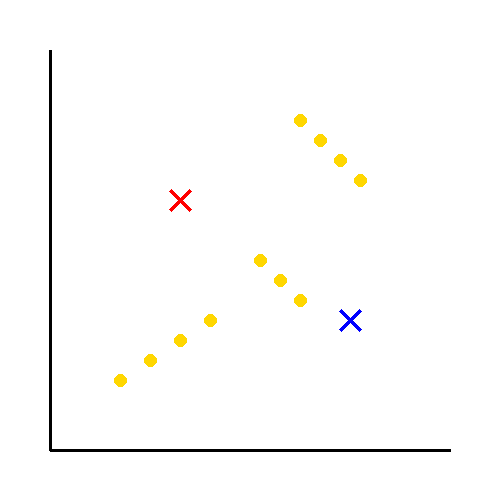<br>
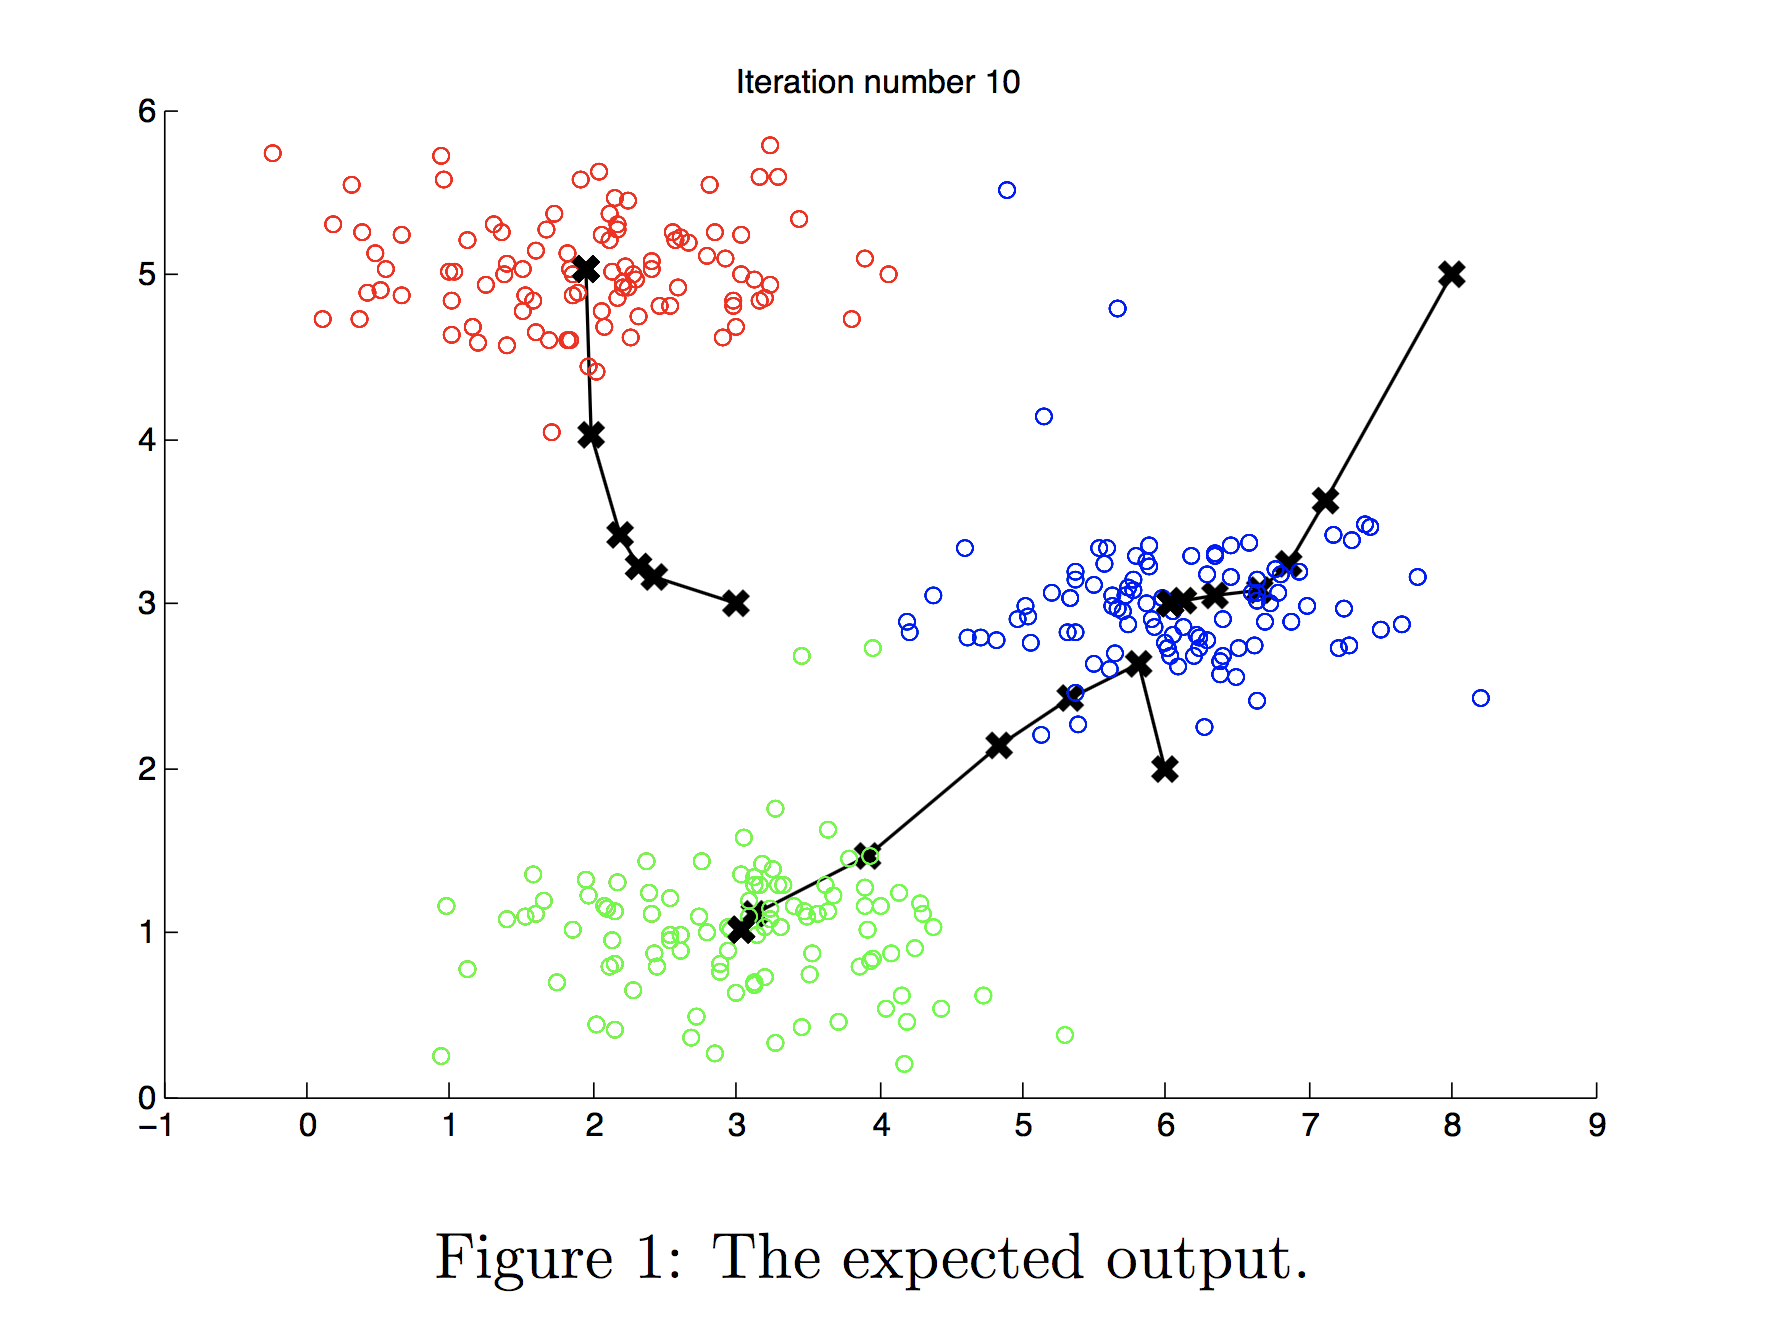<br>最终聚类中心将不会变化,说明算法已经收敛,每个聚类中心对应的*最近点*就是聚类

### K-mean算法

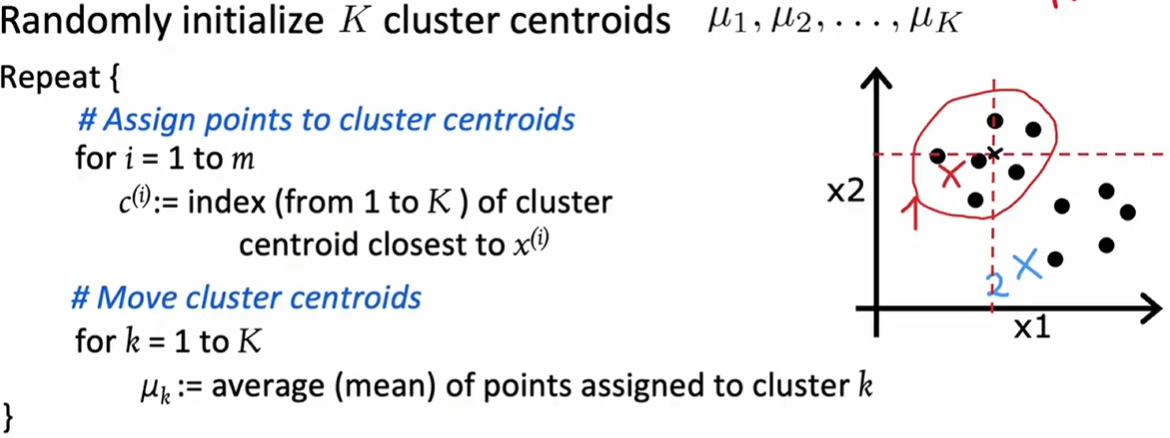

### K-mean的优化对象

我们规定 $c^{(i)}$是[1,K]之间的一个数,代表Sample被分给的**聚类的**编号.(e.g.$x^{(10)}$对应的聚类就是$\mu_{c^{(10)}}$)

算法对应的代价函数(也叫做*失真函数*)为:$$J(c^{(1)},...,c^{(m)},\mu_1,...,\mu_k)=\frac{1}{m}\sum^m_{i=1} \lVert x^{(i)}-\mu_{c^{(i)}} \rVert^2$$

1.对于分配最近点,使得代价函数最小的方式是:固定聚类中心,然后将与聚类中心最近的Sample分到这个聚类中心<br>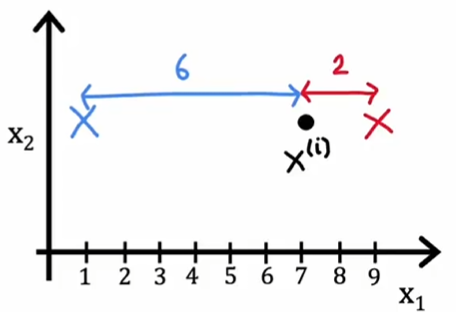<br>2.对于聚类中心的选择,易知平均点可以使得总体最小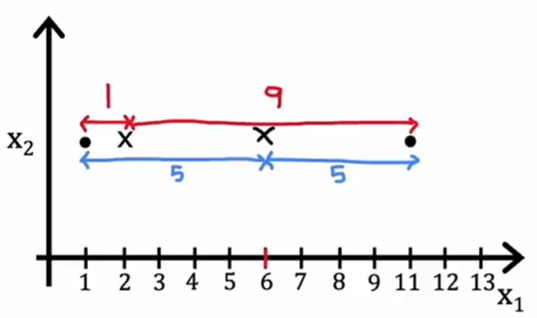<br>
此对应上面的K-mean过程,我们在数学上每次都取最优.也就是说,在正确的情况下,$J$必须是单调不增的

### K-mean的初值

随机选择K个训练样本作为初始的聚类中心<br>
Unluckily,有时随机的初始化会导致Cost Function局部最小<br>
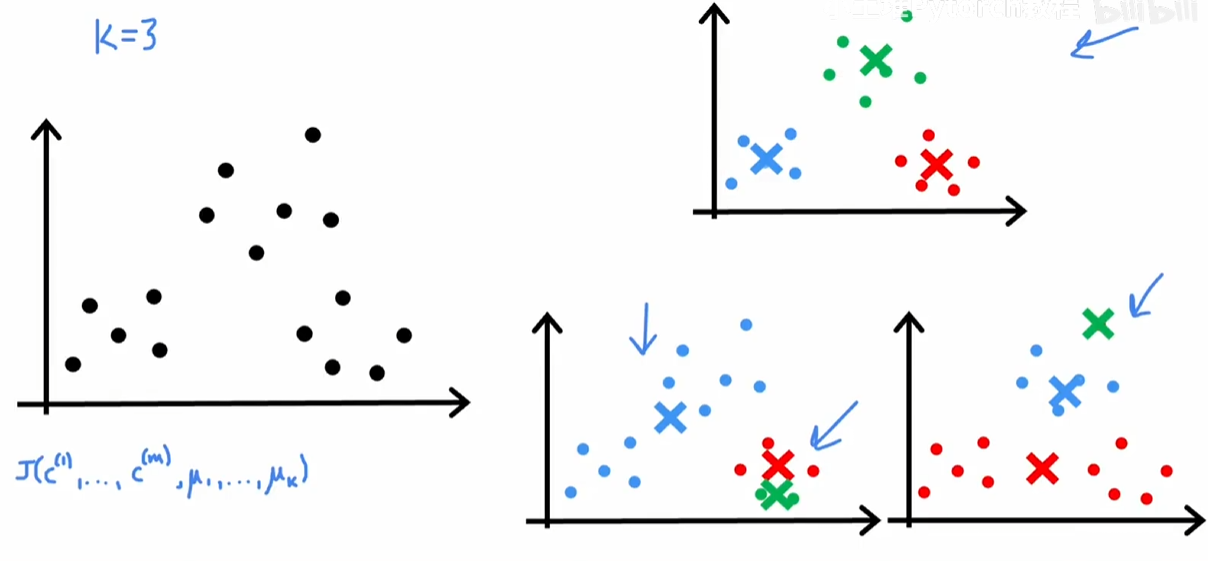
所以我们以不同初始化的聚类位置计算,最终选择代价函数最小的

### K-mean的聚类个数K

Elbow method:选择不同的K,然后运行程序,选择*快速变化的终点即elbow*<br>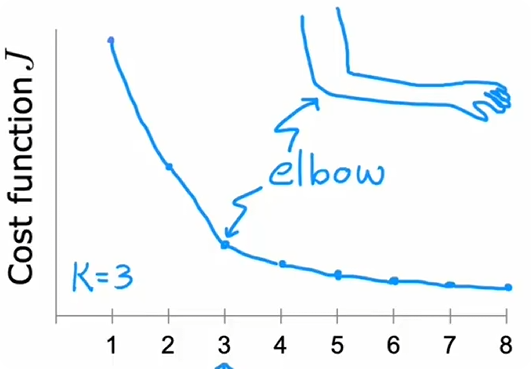

显然最小化J的K是毫无意义的

根据你的需求选择K值:S,M,L或者XS,S,M,L,XL

## 异常检测

### 发现异常事件

已知一个数据集:{$x^{(1)},x^{(2)},...,x^{(m)}$},对于这个数据集的具体要求后说

**密度估计**:估计特征x1,x2的哪些值具有高概率或低概率出现.通过学习算法会得到一个函数$p(x)$.对于一个设定的$\epsilon$,如果$p(x_{test})<\epsilon$,我们就认为其为异常(具体实现见后)<br>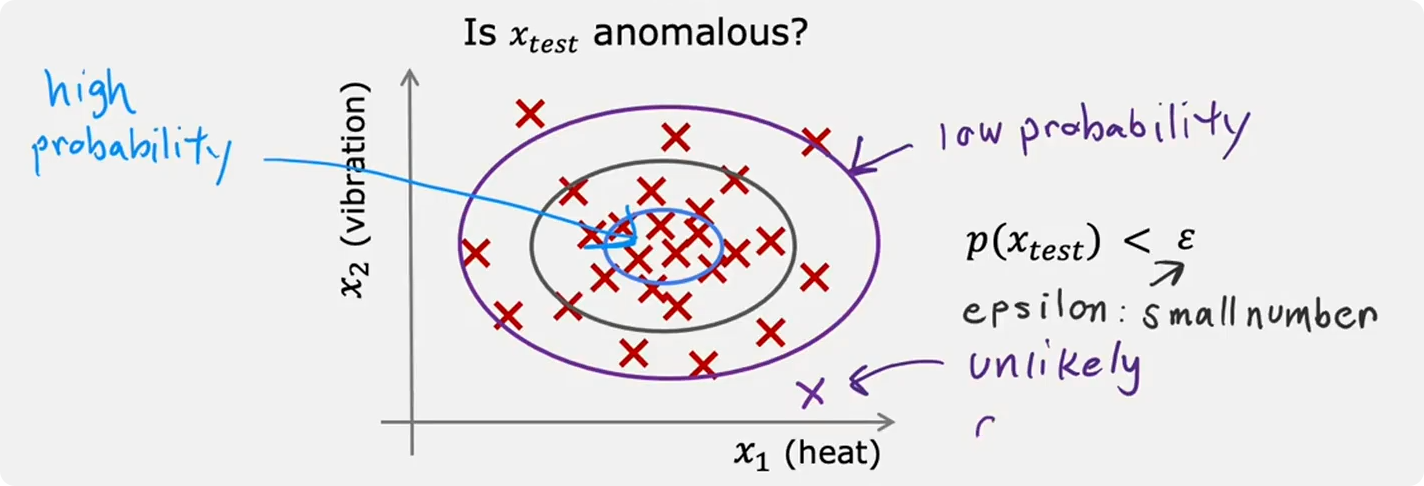

### 正态分布

*注意我们得到的$\mu$以及$\sigma$都只是估计*

### 异常检测算法

对于n个特征的情况$$p(\vec{x})=\prod^n_{i=1}p(x_i;\mu_i,\sigma^2_i)$$我们假设每个特征是独立的(即使不独立对结果也影响甚微)

过程:<br>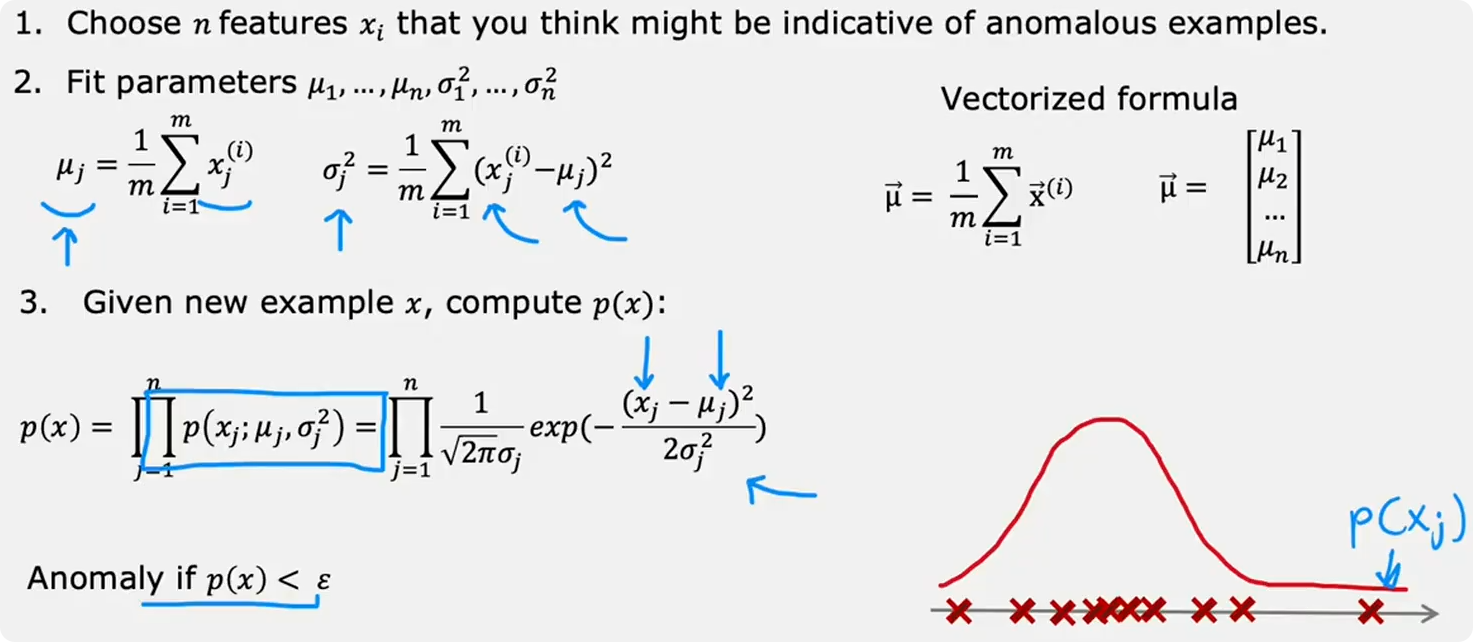

注意到如果$x_{test}$的某个特征过于偏,则会导致连乘的一个分量极小,进而严重拉低整体,这是符合直觉的

### 评估异常检测系统

我们的数据集中包含已知正常和已知异常,但还会混入*未知的异常*.在训练集中,我们假设他们的标签全部为0或者1.在dev集和测试集中,我们掺入一些已知异常.对于那些极其少数的未知异常,它们**并不影响**我们的结果

例子:<br>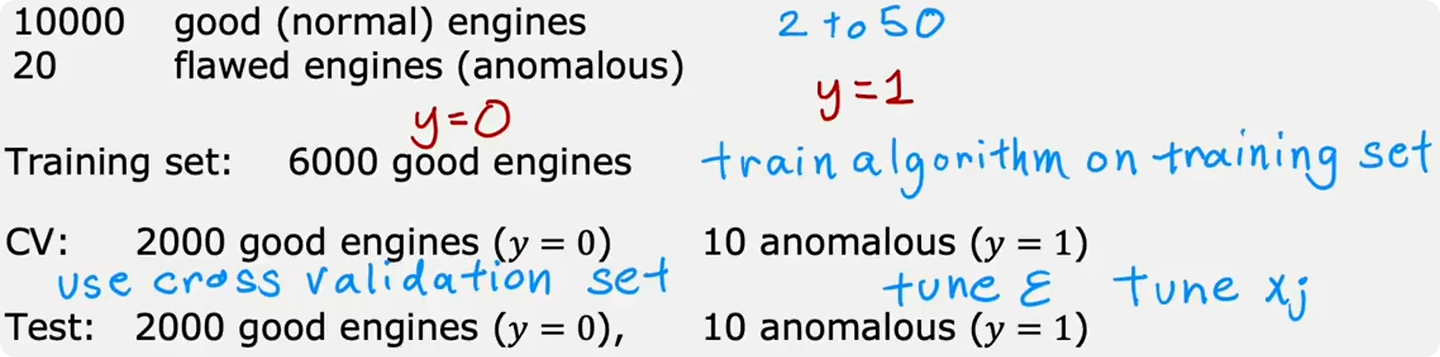

在*已知异常数据较少*的时候,我们将删去测试集并把剩余的数据全部放到dev集中,然后通过增删特征以及调整阈值来达到最佳拟合效果.但是有时会导致在dev集上过拟合,而且你无法测试它(无测试集)

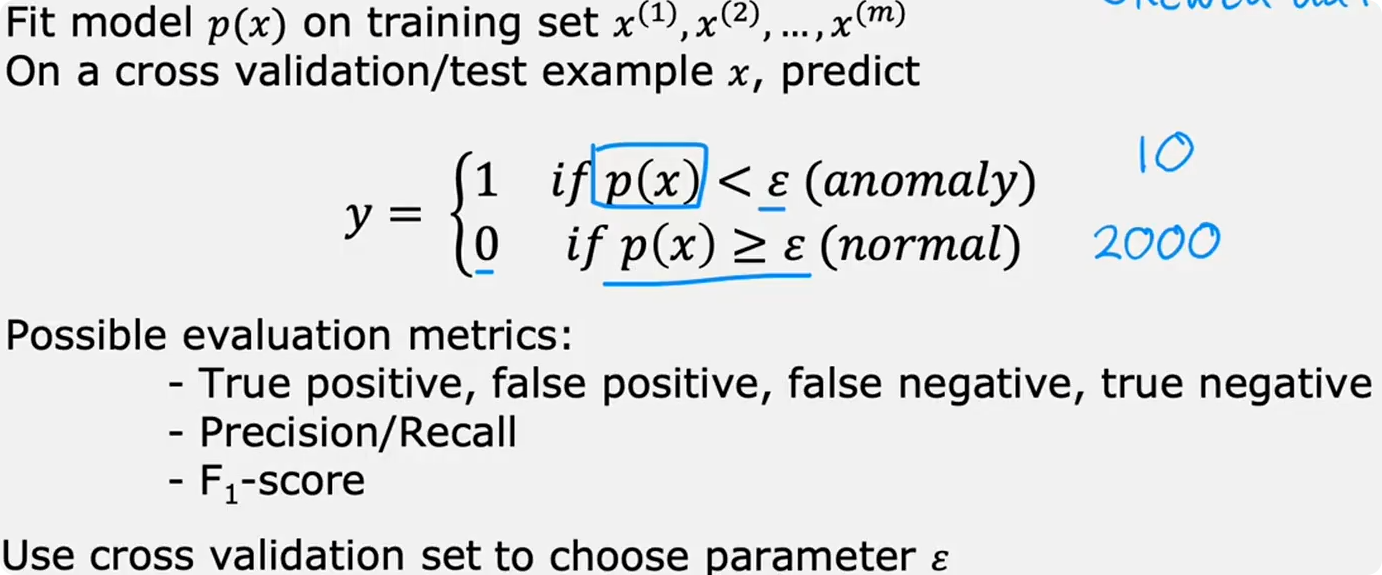

## 异常检测&监督学习

从需求的数据量来说:异常检测需要大量的negative样例和少量(0-20个)的positive样例.<br>监督学习需要大量的negative和positive样例(当然20个positive样例也行)<br>
所以在这方面他们差不多

但是从看待数据的角度:异常检测认为未来的异常不一定和训练的异常一样.<br>监督学习:未来的正常样本可能和训练集里的很像<br>
可以说,异常检测认为所有的小概率事件都是可疑的<br>
e.g.金融诈骗 vs 垃圾邮件

## 选择特征

相比于监督学习可以自行选择权重,异常检测完全依赖被给予的特征

特征需要是高斯分布的.对于非高斯分布,可以通过一些变换,使之变为接近高斯分布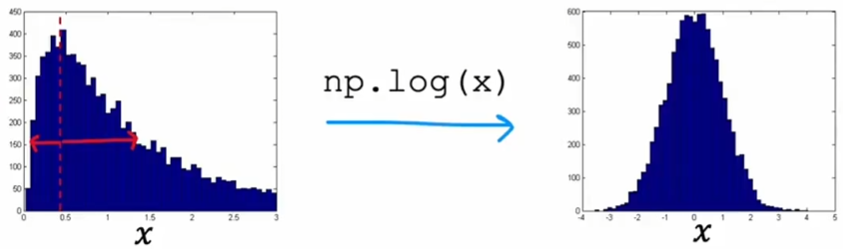

### Error analysis

如果发现有一些错误分类: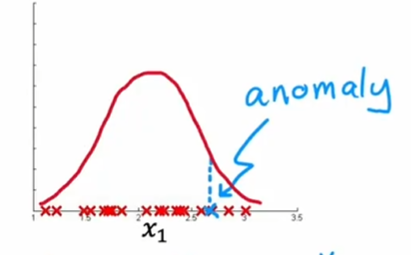<br>我们观察是那些特征导致其误分类了

### 特征工程

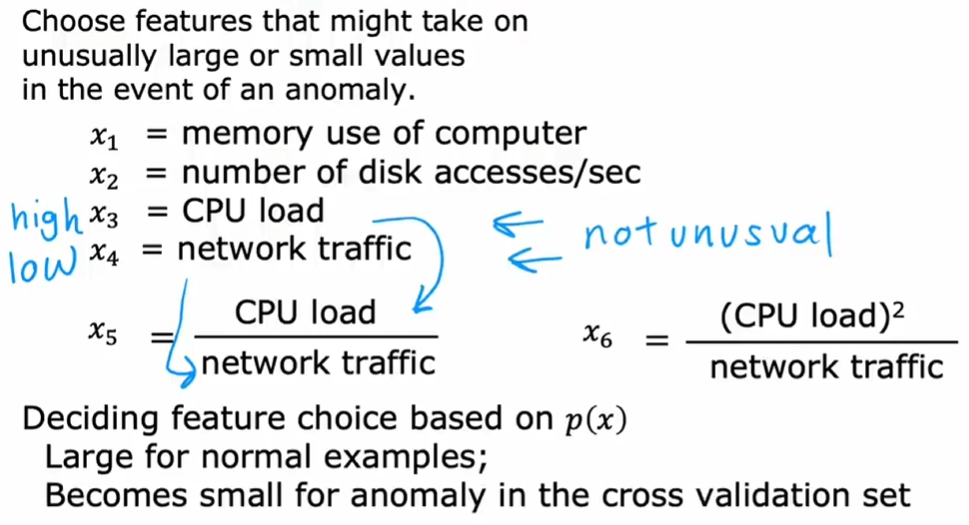